In [3]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 连接OKX
exchange = ccxt.okx()

# 测试：拉取BTC/USDT日线数据
ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", limit=10)
df = pd.DataFrame(ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
df = df.set_index("date")

print(df)

                timestamp     open     high      low    close        volume
date                                                                       
2026-03-19  1773878400000  71253.1  71618.0  68796.3  69923.7   7331.205854
2026-03-20  1773964800000  69923.7  71366.0  69393.5  70515.7   5670.280110
2026-03-21  1774051200000  70515.6  71100.0  68555.0  68921.1   3290.103972
2026-03-22  1774137600000  68921.1  69584.8  67360.1  67860.1   4774.157931
2026-03-23  1774224000000  67860.1  71809.4  67452.4  70900.0  10569.061730
2026-03-24  1774310400000  70900.0  71400.0  68924.0  70557.5   6869.959830
2026-03-25  1774396800000  70557.5  72012.0  70414.1  71334.9   5943.669683
2026-03-26  1774483200000  71334.9  71440.9  68153.3  68827.2   6581.532381
2026-03-27  1774569600000  68827.2  69185.6  65559.6  66403.9   9636.054943
2026-03-28  1774656000000  66403.9  67169.0  65933.2  66736.1   2443.163999


In [4]:
# 拉取更长的历史数据（500天）
ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", limit=500)
df_btc = pd.DataFrame(ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df_btc["date"] = pd.to_datetime(df_btc["timestamp"], unit="ms")
df_btc = df_btc.set_index("date")
df_btc = df_btc.drop(columns=["timestamp"])

# 保存本地
df_btc.to_csv("btc_daily.csv")

print(f"数据维度：{df_btc.shape}")
print(f"时间范围：{df_btc.index[0].date()} 到 {df_btc.index[-1].date()}")
print(df_btc.tail())

数据维度：(300, 5)
时间范围：2025-06-02 到 2026-03-28
               open     high      low    close       volume
date                                                       
2026-03-24  70900.0  71400.0  68924.0  70557.5  6869.959830
2026-03-25  70557.5  72012.0  70414.1  71334.9  5943.669683
2026-03-26  71334.9  71440.9  68153.3  68827.2  6581.532381
2026-03-27  68827.2  69185.6  65559.6  66403.9  9636.054943
2026-03-28  66403.9  67169.0  65933.2  66738.0  2443.306740


In [5]:
# 分批拉取更长历史数据
all_ohlcv = []
since = exchange.parse8601("2023-01-01T00:00:00Z")

while True:
    ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", since=since, limit=300)
    if len(ohlcv) == 0:
        break
    all_ohlcv += ohlcv
    since = ohlcv[-1][0] + 86400000  # 下一天
    if ohlcv[-1][0] >= exchange.milliseconds():
        break
    time.sleep(0.5)

df_btc = pd.DataFrame(all_ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df_btc["date"] = pd.to_datetime(df_btc["timestamp"], unit="ms")
df_btc = df_btc.set_index("date")
df_btc = df_btc.drop(columns=["timestamp"])
df_btc = df_btc[~df_btc.index.duplicated()]
df_btc.to_csv("btc_daily.csv")

print(f"数据维度：{df_btc.shape}")
print(f"时间范围：{df_btc.index[0].date()} 到 {df_btc.index[-1].date()}")

数据维度：(1183, 5)
时间范围：2023-01-01 到 2026-03-28


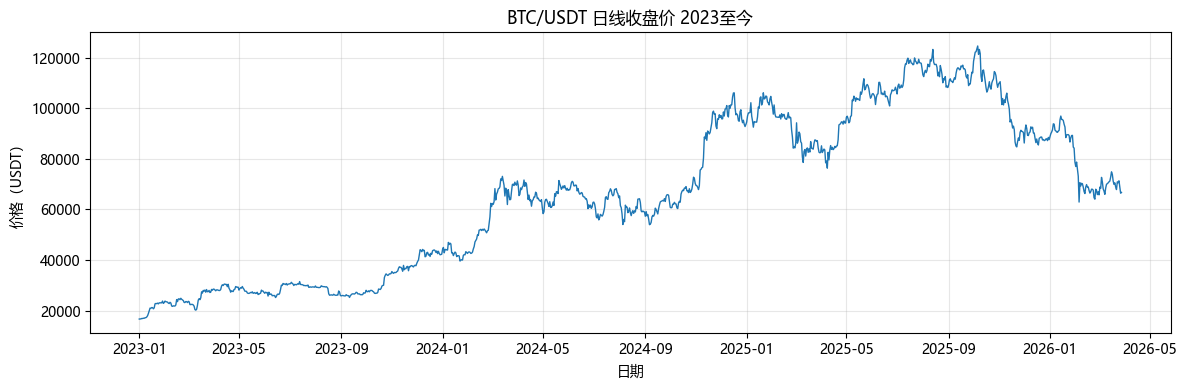

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df_btc.index, df_btc["close"], linewidth=1)
plt.title("BTC/USDT 日线收盘价 2023至今")
plt.xlabel("日期")
plt.ylabel("价格（USDT）")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
symbols = [
    "BTC/USDT", "ETH/USDT", "BNB/USDT", "SOL/USDT", "XRP/USDT",
    "DOGE/USDT", "ADA/USDT", "TRX/USDT", "HYPE/USDT", "LINK/USDT"
]

close_crypto = {}

for symbol in symbols:
    try:
        ohlcv = []
        since = exchange.parse8601("2023-01-01T00:00:00Z")
        while True:
            batch = exchange.fetch_ohlcv(symbol, timeframe="1d", since=since, limit=300)
            if len(batch) == 0:
                break
            ohlcv += batch
            since = batch[-1][0] + 86400000
            if batch[-1][0] >= exchange.milliseconds():
                break
            time.sleep(0.3)
        
        df_temp = pd.DataFrame(ohlcv, columns=["timestamp","open","high","low","close","volume"])
        df_temp["date"] = pd.to_datetime(df_temp["timestamp"], unit="ms")
        df_temp = df_temp.set_index("date")["close"]
        df_temp = df_temp[~df_temp.index.duplicated()]
        close_crypto[symbol.replace("/USDT","")] = df_temp
        print(f"完成：{symbol}")
        time.sleep(0.5)
    except Exception as e:
        print(f"失败：{symbol} {e}")

close_crypto_df = pd.DataFrame(close_crypto)
close_crypto_df.to_csv("crypto_close.csv")
print(f"\n完成，维度：{close_crypto_df.shape}")

完成：BTC/USDT
完成：ETH/USDT
完成：BNB/USDT


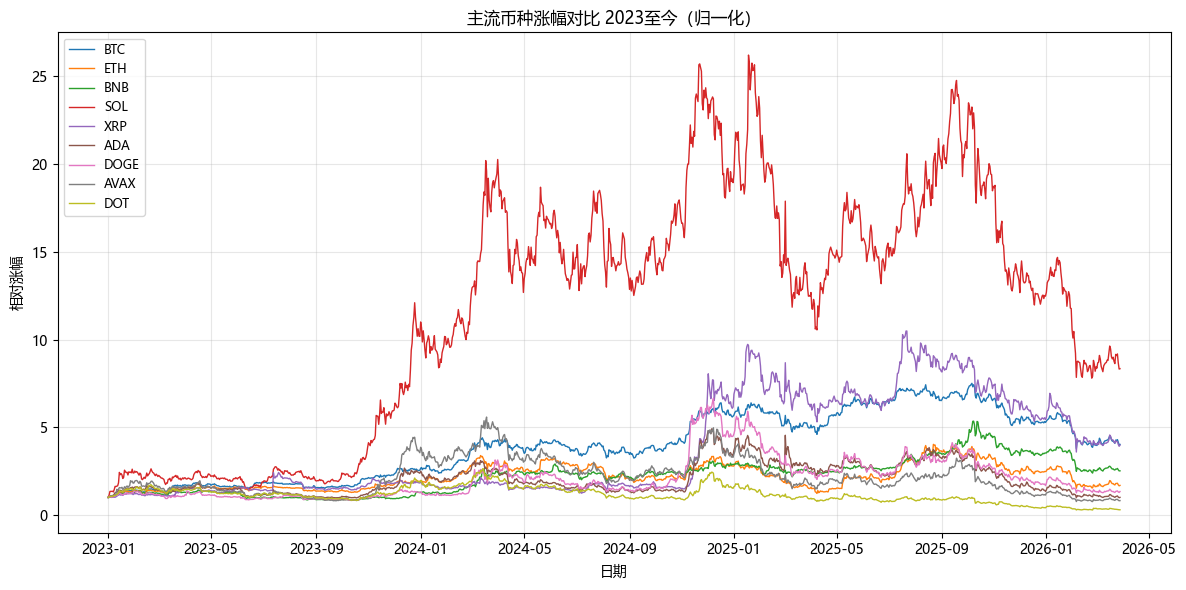

In [8]:
# 归一化到1，方便对比
close_norm = close_crypto_df / close_crypto_df.iloc[0]

plt.figure(figsize=(12, 6))
for col in close_norm.columns:
    plt.plot(close_norm.index, close_norm[col], linewidth=1, label=col)

plt.title("主流币种涨幅对比 2023至今（归一化）")
plt.xlabel("日期")
plt.ylabel("相对涨幅")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()